# Welcome to HiMaLAYAS Advanced Quickstart

This notebook provides an advanced, end-to-end example of **Hierarchical Matrix Layout and Annotation Software (HiMaLAYAS)** for post hoc enrichment-based annotation and visualization of hierarchically clustered matrices.

In this quickstart, we recreate the zoomed view shown in **Figure 1C** of the HiMaLAYAS manuscript. Starting from the same parent-level yeast reference analysis as the basic quickstart, we subset the parent cluster enriched for mRNA splicing and rerun HiMaLAYAS within that selected matrix to resolve finer dendrogram-defined subclusters.

You will learn how to:
- Load a matrix and GO BP annotations
- Run the Figure 1B parent-level reference analysis
- Subset a dendrogram-defined parent cluster
- Rerun clustering and enrichment inside the selected cluster
- Plot the Figure 1C zoomed view with essentiality and single-mutant fitness rails
- Plot condensed hierarchy views

Expected input files in `data`:
- `gi_pcc_sampled.tsv`
- `go_bp_name_to_orfs.json`
- `yeast_essential_orfs.txt`
- `strain_ids_and_single_mutant_fitness.csv`


---

## Setup

Enable inline plotting and define the figure export paths.


In [1]:
# Enable inline plotting for notebooks
%matplotlib inline
# Keep inline notebook figures lightweight for GitHub and Binder rendering.
%config InlineBackend.rc = {'figure.dpi': 72}

In [2]:
from pathlib import Path
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"Dropped .* annotations after matrix filtering.*",
    category=RuntimeWarning,
)

---

## Load GO BP Annotations

Load GO BP term-to-ORF mappings.


GO BP terms loaded: 1,095
Min term size: 5
Max term size: 243
Unique ORFs across all terms: 4,927


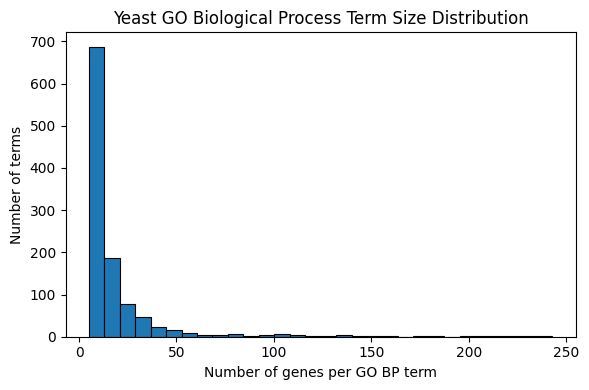

In [3]:
# Loads pre-filtered GO BP annotations and visualizes term sizes.
import json

import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = Path("data")
GO_BP_PATH = DATA_DIR / "go_bp_name_to_orfs.json"

# Load GO Biological Process term -> ORF mapping (already filtered upstream)
with GO_BP_PATH.open("r", encoding="utf-8") as fh:
    go_bp = json.load(fh)

# Compute term sizes and global ORF coverage
term_sizes = [len(set(orfs)) for orfs in go_bp.values()]
all_orfs = {orf for orfs in go_bp.values() for orf in orfs}

# Summary statistics reported in the manuscript
print(f"GO BP terms loaded: {len(term_sizes):,}")
print(f"Min term size: {min(term_sizes)}")
print(f"Max term size: {max(term_sizes)}")
print(f"Unique ORFs across all terms: {len(all_orfs):,}")

# Histogram of GO BP term sizes
plt.figure(figsize=(6, 4))
plt.hist(
    term_sizes,
    bins=30,
    edgecolor="black",
    linewidth=0.8,
)
plt.xlabel("Number of genes per GO BP term")
plt.ylabel("Number of terms")
plt.title("Yeast GO Biological Process Term Size Distribution")
plt.tight_layout()
plt.show()

# Optional: save figures locally (Binder storage is temporary).
SAVE_FIGURES = False

if SAVE_FIGURES:
    Path("outputs").mkdir(exist_ok=True)
    plt.savefig("outputs/quickstart_advanced_go_bp_term_sizes.png", dpi=300, bbox_inches="tight")
# Use Helvetica globally for notebook figures.
plt.rcParams["font.family"] = "Helvetica"
plt.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]

---

## Load the Matrix

Load the genetic interaction profile similarity matrix. Rows and columns should have identical ORF labels.


In [4]:
import pandas as pd

MATRIX_PATH = DATA_DIR / "gi_pcc_sampled.tsv"

# Load genetic interaction profile similarity matrix (ORF × ORF)
DF_GI_PCC = pd.read_csv(
    MATRIX_PATH,
    sep="\t",
    index_col=0,
)

# Sanity checks
print(f"Matrix shape: {DF_GI_PCC.shape[0]:,} × {DF_GI_PCC.shape[1]:,}")
print(f"Row/column labels identical: {DF_GI_PCC.index.equals(DF_GI_PCC.columns)}")
print(f"Value range: [{DF_GI_PCC.min().min():.3f}, {DF_GI_PCC.max().max():.3f}]")

# Post hoc row rails: ORF essentiality and Costanzo et al. (2016) single-mutant fitness.
ESSENTIAL_PATH = DATA_DIR / "yeast_essential_orfs.txt"
FITNESS_PATH = DATA_DIR / "strain_ids_and_single_mutant_fitness.csv"

essential_orfs = {line.strip() for line in ESSENTIAL_PATH.read_text().splitlines() if line.strip()}
orf_essential_map = {
    orf: ("essential" if orf in essential_orfs else "nonessential") for orf in DF_GI_PCC.index
}
ESSENTIAL_COLORS = {"essential": "#333333", "nonessential": "white"}

fitness_df = pd.read_csv(FITNESS_PATH)
orf_fitness_map = (
    fitness_df.groupby("Systematic gene name")["Single mutant fitness (30°)"]
    .mean()
    .reindex(DF_GI_PCC.index)
    .to_dict()
)
# log2-transform fitness so reduced fitness (log2 < 0) reads as the salient signal.
# Non-positive or missing values stay NaN and render as missing.
orf_log2_fitness_map = {
    orf: (np.log2(value) if value is not None and value == value and value > 0 else np.nan)
    for orf, value in orf_fitness_map.items()
}

print(f"Essential in matrix: {sum(v == 'essential' for v in orf_essential_map.values())}")
print(
    f"log2 fitness values available: {sum(v == v for v in orf_log2_fitness_map.values())}/{len(orf_log2_fitness_map)}"
)

Matrix shape: 1,053 × 1,053
Row/column labels identical: True
Value range: [-0.317, 0.845]
Essential in matrix: 339
log2 fitness values available: 993/1053


---

## Run the Parent-Level Reference Analysis

Run the same parent-level analysis used for Figure 1B so that the Figure 1C parent cluster can be selected.


In [5]:
import himalayas
from himalayas import Analysis, Annotations, Matrix

print(f"HiMaLAYAS version: {himalayas.__version__}\n")

REFERENCE_CONFIG = dict(
    linkage_method="ward",
    linkage_metric="euclidean",
    linkage_threshold=16,
    optimal_ordering=True,
    min_cluster_size=30,
)
MIN_OVERLAP = 2
QVAL_CUTOFF = 0.05

# Build core objects
matrix = Matrix(DF_GI_PCC)
annotations = Annotations(
    go_bp,
    matrix,
)

# Run clustering + enrichment
analysis = (
    Analysis(matrix, annotations)
    .cluster(**REFERENCE_CONFIG)
    .enrich(min_overlap=MIN_OVERLAP)
    .finalize(
        col_cluster=True,
    )
)
results = analysis.results
# Keep significant terms
results_sig = results.filter(f"qval <= {QVAL_CUTOFF}")

cluster_labels = results_sig.cluster_labels(
    rank_by="q",
    label_mode="top_term",
)

assert (len(results.df), len(results_sig.df), len(results.clusters.cluster_sizes)) == (
    709,
    331,
    7,
), "Genetic interaction profile similarity reference clustering result changed from expected publication values"

print(f"All enriched rows: {len(results.df):,}")
print(f"Significant cluster-term pairs (q<=0.05): {len(results_sig.df):,}")
print(cluster_labels)

HiMaLAYAS version: 0.0.16

All enriched rows: 709
Significant cluster-term pairs (q<=0.05): 331
   cluster                                              label          pval  \
0        1                    GPI anchor biosynthetic process  3.222730e-12   
1        2                         vesicle-mediated transport  1.237408e-26   
2        3                     mRNA splicing, via spliceosome  2.829998e-16   
3        4                            cytoplasmic translation  8.925220e-15   
4        5  mitochondrial respiratory chain complex IV ass...  1.794876e-19   
5        6                                    DNA replication  1.798541e-42   
6        7                                      cell division  2.138848e-20   

           qval         score    n  \
0  8.788137e-11  8.788137e-11  148   
1  4.386613e-24  4.386613e-24   92   
2  1.433192e-14  1.433192e-14  263   
3  3.954988e-13  3.954988e-13  358   
4  1.590709e-17  1.590709e-17   78   
5  1.275166e-39  1.275166e-39   52   
6  2.

---

## Render the Parent-Level Matrix

Render the parent-level matrix before zooming, with post hoc essentiality and single-mutant fitness rails.


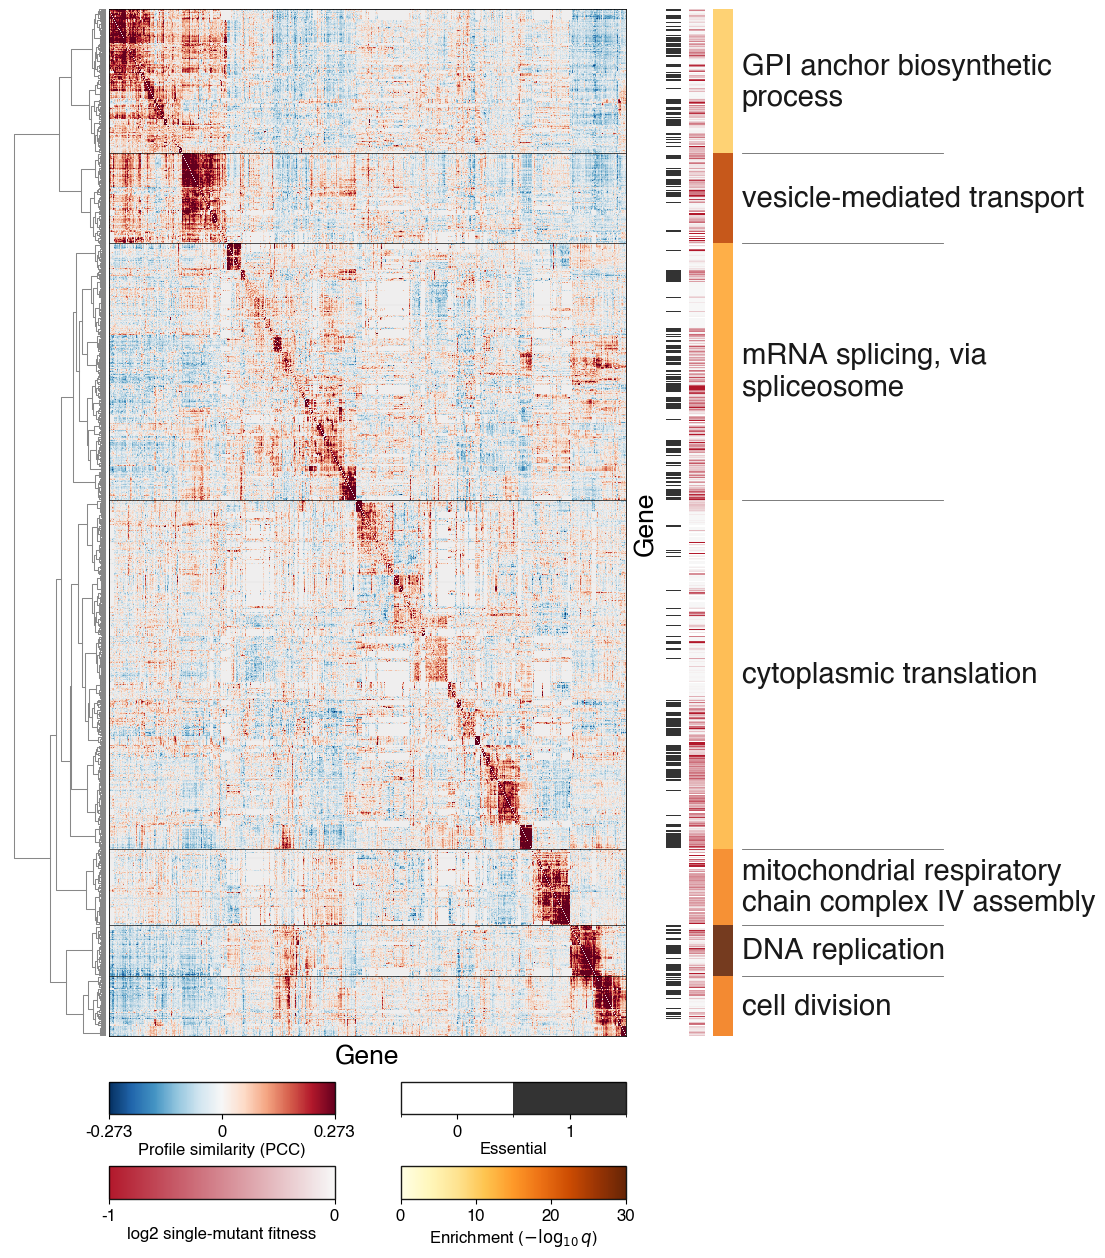

In [6]:
import numpy as np
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, ListedColormap, Normalize
from himalayas.plot import Plotter

LABEL_COLOR = "black"
BACKGROUND_COLOR = "white"
DENDRO_COLOR = "#888888"
FONT = "DejaVu Sans"
MATRIX_CMAP = "RdBu_r"
MATRIX_LW = 0.6
ENRICHMENT_CMAP = "YlOrBr"
FITNESS_CMAP = LinearSegmentedColormap.from_list("Log2FitnessDefect", ["#b2182b", "#f7f7f7"])


def make_discrete_palette(nonessential="white", essential="#333333", name="Essentiality"):
    """Build a two-level colormap and norm for essential/nonessential."""
    cmap = ListedColormap([nonessential, essential], name=name)
    norm = BoundaryNorm(boundaries=[-0.5, 0.5, 1.5], ncolors=cmap.N)
    return cmap, norm


ESSENTIAL_CMAP, ESSENTIAL_NORM = make_discrete_palette(
    nonessential=ESSENTIAL_COLORS["nonessential"],
    essential=ESSENTIAL_COLORS["essential"],
)
FITNESS_VMIN = -1.0
FITNESS_VMAX = 0.0
FITNESS_NORM = Normalize(vmin=FITNESS_VMIN, vmax=FITNESS_VMAX)
ENRICHMENT_NORM = Normalize(0, 30)

vals = matrix.values
mask = np.isfinite(vals) & (vals != 0)
vlim = float(np.percentile(np.abs(vals[mask]), 99))

plotter = (
    Plotter(results_sig)
    .set_background(color=BACKGROUND_COLOR)
    .plot_dendrogram(
        axes=[0.06, 0.16, 0.09, 0.79],
        data_pad=0.35,
        color=DENDRO_COLOR,
        linewidth=0.75,
    )
    .set_figure(
        figsize=(11, 13),
        subplots_adjust={"left": 0.15, "right": 0.62, "bottom": 0.16, "top": 0.95},
    )
    .plot_matrix(
        cmap=MATRIX_CMAP,
        center=0,
        vmin=-vlim,
        vmax=vlim,
        outer_lw=MATRIX_LW,
        outer_color=LABEL_COLOR,
    )
    .plot_matrix_axis_labels(
        xlabel="Gene",
        ylabel="Gene",
        fontsize=19,
        font=FONT,
        fontweight="normal",
        color=LABEL_COLOR,
        xlabel_pad=6.0,
        ylabel_pad=0.011,
    )
    .set_label_panel(
        axes=[0.62, 0.16, 0.36, 0.79],
        gutter_color=BACKGROUND_COLOR,
        text_pad=0.012,
    )
    .plot_cluster_labels(
        rank_by="q",
        label_mode="top_term",
        max_words=30,
        wrap_text=True,
        wrap_width=26,
        overflow="wrap",
        font=FONT,
        fontsize=21,
        color=LABEL_COLOR,
        skip_unlabeled=False,
        label_fields=("label",),
        omit_words=(),
        boundary_color=LABEL_COLOR,
        boundary_lw=MATRIX_LW,
        boundary_alpha=0.8,
        label_sep_xmin=None,
        label_sep_xmax=0.8,
        label_sep_color=LABEL_COLOR,
        label_sep_lw=MATRIX_LW,
        label_sep_alpha=0.6,
    )
    .plot_label_bar(
        values=orf_essential_map,
        mode="categorical",
        colors=ESSENTIAL_COLORS,
        name="essentiality",
        title="Essential",
        width=0.04,
        left_pad=0.07,
        right_pad=0.0,
    )
    .plot_label_bar(
        values=orf_log2_fitness_map,
        mode="continuous",
        cmap=FITNESS_CMAP,
        vmin=FITNESS_VMIN,
        vmax=FITNESS_VMAX,
        missing_color=BACKGROUND_COLOR,
        name="fitness",
        title="SMF",
        width=0.04,
        left_pad=0.02,
        right_pad=0.0,
    )
    .plot_cluster_bar(
        norm=ENRICHMENT_NORM,
        name="sigbar",
        title="Enrichment",
        width=0.05,
        left_pad=0.02,
        right_pad=0.01,
    )
    .add_colorbar(
        name="matrix",
        cmap=MATRIX_CMAP,
        norm=Normalize(-vlim, vlim),
        label="Profile similarity (PCC)",
        ticks=[-vlim, 0, vlim],
    )
    .set_label_track_order(("essentiality", "fitness", "sigbar"))
    .add_colorbar(
        name="essentiality",
        cmap=ESSENTIAL_CMAP,
        norm=ESSENTIAL_NORM,
        label="Essential",
        ticks=[0, 1],
    )
    .add_colorbar(
        name="fitness",
        cmap=FITNESS_CMAP,
        norm=FITNESS_NORM,
        label="log2 single-mutant fitness",
        ticks=[FITNESS_VMIN, FITNESS_VMAX],
    )
    .add_colorbar(
        name="enrichment",
        cmap=ENRICHMENT_CMAP,
        norm=ENRICHMENT_NORM,
        label=r"Enrichment ($-\log_{10}q$)",
        ticks=[0, 10, 20, 30],
    )
    .plot_colorbars(
        ncols=2,
        height=0.09,
        gap=0.035,
        label_pad=2.0,
        hpad=0.06,
        vpad=0.04,
        fontsize=12,
        font=FONT,
        color=LABEL_COLOR,
        border_color=LABEL_COLOR,
        border_width=1.0,
        border_alpha=0.9,
        tick_decimals=3,
    )
)

plotter.show()

# Optional: save figures locally (Binder storage is temporary).
SAVE_FIGURES = False

if SAVE_FIGURES:
    Path("outputs").mkdir(exist_ok=True)
    plotter.save("outputs/quickstart_advanced_matrix.png", dpi=300, bbox_inches="tight")

---

## Condensed Dendrogram

Summarize the parent-level hierarchy as a condensed dendrogram with cluster labels and the enrichment significance track.

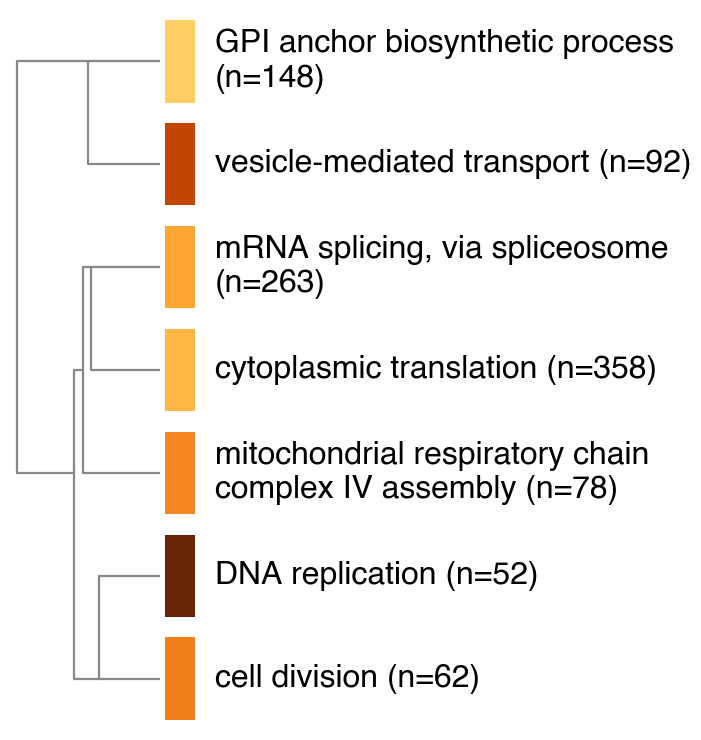

In [7]:
from himalayas.plot import plot_dendrogram_condensed

MATRIX_CONDENSED_LW = 1.6

full_condensed = plot_dendrogram_condensed(
    results_sig,
    rank_by="q",
    label_mode="top_term",
    figsize=(5, 8),
    dendrogram_width=0.3,
    sigbar_cmap=ENRICHMENT_CMAP,
    sigbar_width=0.06,
    sigbar_height=0.8,
    sigbar_min_logp=0.0,
    sigbar_max_logp=30.0,
    font=FONT,
    fontsize=23,
    max_words=40,
    wrap_text=True,
    wrap_width=34,
    overflow="ellipsis",
    omit_words=(),
    label_fields=("label", "n"),
    label_color=LABEL_COLOR,
    label_left_pad=0.04,
    dendrogram_color=DENDRO_COLOR,
    dendrogram_lw=MATRIX_CONDENSED_LW,
    background_color=BACKGROUND_COLOR,
)
full_condensed.show()

# Optional: save figures locally (Binder storage is temporary).
SAVE_FIGURES = False

if SAVE_FIGURES:
    Path("outputs").mkdir(exist_ok=True)
    full_condensed.save(
        "outputs/quickstart_advanced_condensed.png", dpi=300, bbox_inches="tight", pad_inches=0.02
    )

---

## Zoom into Cluster 3

Subset the parent cluster enriched for mRNA splicing and rerun HiMaLAYAS on the selected-cluster submatrix.


In [8]:
PARENT_CLUSTER_ID = 3
parent_n_genes = int(results.clusters.cluster_sizes[PARENT_CLUSTER_ID])
parent_top_term = cluster_labels.loc[cluster_labels["cluster"] == PARENT_CLUSTER_ID, "label"].iloc[
    0
]
PARENT_LIKE_TERMS = {parent_top_term, "RNA splicing"}

ZOOM_CONFIG = dict(
    linkage_method="ward",
    linkage_metric="euclidean",
    linkage_threshold="auto",
    optimal_ordering=True,
    min_cluster_size=20,
)

zoom_view = results.subset(cluster=PARENT_CLUSTER_ID)
zoom_matrix = zoom_view.matrix
zoom_annotations = Annotations(go_bp, zoom_matrix)
zoom_analysis = (
    Analysis(zoom_matrix, zoom_annotations)
    .cluster(**ZOOM_CONFIG)
    .enrich(min_overlap=MIN_OVERLAP, background=results.matrix)
    .finalize(col_cluster=True)
)
zoom_results = zoom_analysis.results
zoom_results_sig = zoom_results.filter(f"qval <= {QVAL_CUTOFF}")

evidence_rows = []
for cid in sorted(zoom_results.clusters.unique_clusters):
    sub = zoom_results_sig.df[zoom_results_sig.df["cluster"] == cid].sort_values("pval")
    top = sub.iloc[0] if len(sub) else None
    n = int(zoom_results.clusters.cluster_sizes[cid])
    if top is None:
        top_term, status = None, "no_significant_term"
    else:
        top_term = top["term"]
        status = (
            "parent_like_label"
            if top_term in PARENT_LIKE_TERMS
            else "refined_or_complementary_label"
        )
    evidence_rows.append(
        {"zoom_cluster_id": cid, "n_genes": n, "top_term": top_term, "status": status}
    )
evidence_table = pd.DataFrame(evidence_rows)

n_refined = (evidence_table["status"] == "refined_or_complementary_label").sum()
n_parent_like = (evidence_table["status"] == "parent_like_label").sum()
n_unlabeled = (evidence_table["status"] == "no_significant_term").sum()
n_labeled = len(evidence_table) - n_unlabeled
genes_refined = int(
    evidence_table.loc[
        evidence_table["status"] == "refined_or_complementary_label", "n_genes"
    ].sum()
)
genes_labeled = int(
    evidence_table.loc[evidence_table["status"] != "no_significant_term", "n_genes"].sum()
)
genes_total = int(evidence_table["n_genes"].sum())

print(
    f"Zoom of cluster {PARENT_CLUSTER_ID} ({parent_n_genes} genes) resolves into {len(evidence_table)} subclusters:"
)
print(
    f"  {n_labeled} significant labels, including {n_refined} refined/complementary and {n_parent_like} parent-like; {n_unlabeled} unlabeled"
)
print(
    f"  Genes covered by significant labels: {genes_labeled}/{genes_total} ({genes_labeled/genes_total:.1%})"
)
print(
    f"  Genes covered by refined/complementary labels: {genes_refined}/{genes_total} ({genes_refined/genes_total:.1%})"
)
assert (
    len(evidence_table),
    n_labeled,
    n_refined,
    n_parent_like,
    n_unlabeled,
    genes_labeled,
    genes_total,
) == (7, 7, 6, 1, 0, 263, 263), "Cluster 3 zoom result changed from expected publication values"

Zoom of cluster 3 (263 genes) resolves into 7 subclusters:
  7 significant labels, including 6 refined/complementary and 1 parent-like; 0 unlabeled
  Genes covered by significant labels: 263/263 (100.0%)
  Genes covered by refined/complementary labels: 234/263 (89.0%)


---

## Render the Figure 1C Zoom

Render the cluster 3 zoomed view with refined GO BP labels plus the same post hoc essentiality and single-mutant fitness rails.


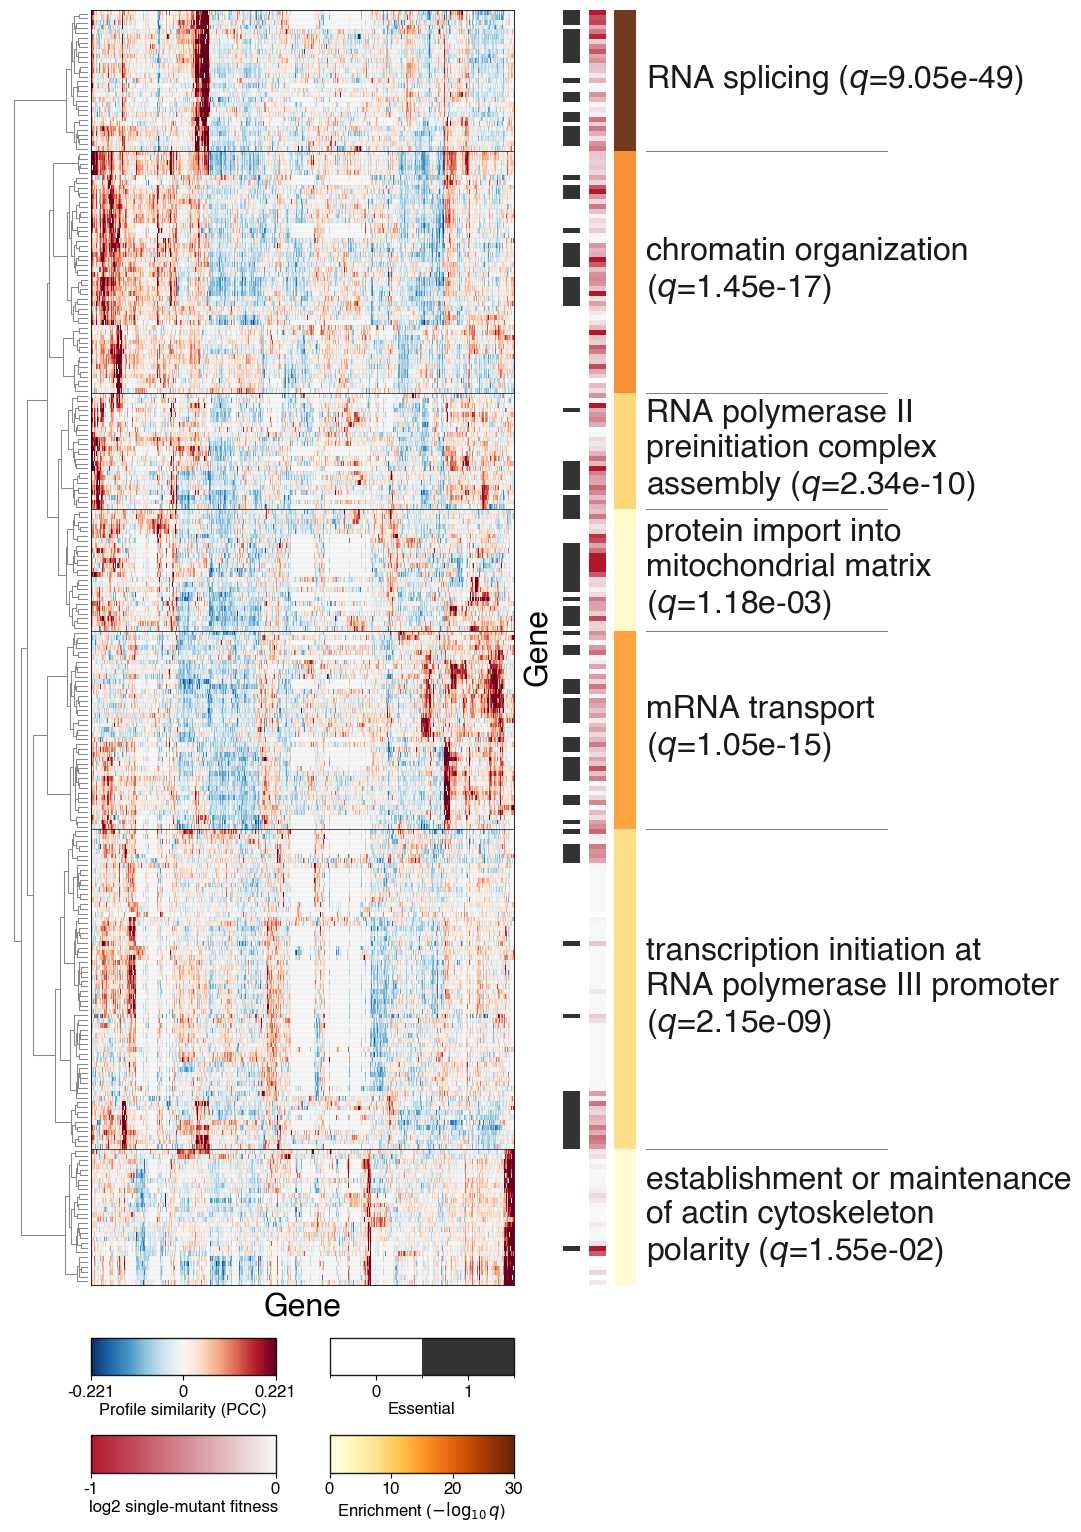

In [9]:
# Render the cluster 3 zoom.
zoom_vals = zoom_matrix.values
zoom_mask = np.isfinite(zoom_vals) & (zoom_vals != 0)
zoom_vlim = float(np.percentile(np.abs(zoom_vals[zoom_mask]), 99))

panel_c_plotter = (
    Plotter(zoom_results_sig)
    .set_background(color=BACKGROUND_COLOR)
    .plot_dendrogram(
        axes=[0.06, 0.06, 0.09, 0.85],
        data_pad=0.75,
        color=DENDRO_COLOR,
        linewidth=0.75,
    )
    .set_figure(
        figsize=(9, 15),
        subplots_adjust={
            "left": 0.15,
            "right": 0.62,
            "bottom": 0.06,
            "top": 0.91,
        },
    )
    .plot_matrix(
        cmap=MATRIX_CMAP,
        center=0,
        vmin=-zoom_vlim,
        vmax=zoom_vlim,
        outer_lw=MATRIX_LW,
        outer_color=LABEL_COLOR,
    )
    .plot_matrix_axis_labels(
        xlabel="Gene",
        ylabel="Gene",
        fontsize=23,
        font=FONT,
        fontweight="normal",
        color=LABEL_COLOR,
        xlabel_pad=6.0,
        ylabel_pad=0.02,
    )
    .set_label_panel(
        axes=[0.62, 0.06, 0.36, 0.85],
        gutter_color=BACKGROUND_COLOR,
        text_pad=0.012,
    )
    .plot_cluster_labels(
        rank_by="q",
        label_mode="top_term",
        max_words=30,
        wrap_text=True,
        wrap_width=28,
        overflow="wrap",
        font=FONT,
        fontsize=23,
        color=LABEL_COLOR,
        skip_unlabeled=False,
        placeholder_text="(no significant term)",
        placeholder_color="#777777",
        placeholder_alpha=0.9,
        label_fields=("label", "q"),
        omit_words=(),
        boundary_color=LABEL_COLOR,
        boundary_lw=MATRIX_LW,
        boundary_alpha=0.8,
        label_sep_xmin=None,
        label_sep_xmax=1.15,
        label_sep_color=LABEL_COLOR,
        label_sep_lw=MATRIX_LW,
        label_sep_alpha=0.6,
    )
    .plot_label_bar(
        values=orf_essential_map,
        mode="categorical",
        colors=ESSENTIAL_COLORS,
        name="essentiality",
        title="Essential",
        width=0.055,
        left_pad=0.12,
        right_pad=0.0,
    )
    .plot_label_bar(
        values=orf_log2_fitness_map,
        mode="continuous",
        cmap=FITNESS_CMAP,
        vmin=FITNESS_VMIN,
        vmax=FITNESS_VMAX,
        missing_color=BACKGROUND_COLOR,
        name="fitness",
        title="SMF",
        width=0.055,
        left_pad=0.025,
        right_pad=0.0,
    )
    .plot_cluster_bar(
        norm=ENRICHMENT_NORM,
        name="sigbar",
        title="Enrichment",
        width=0.065,
        left_pad=0.025,
        right_pad=0.02,
    )
    .add_colorbar(
        name="matrix",
        cmap=MATRIX_CMAP,
        norm=Normalize(-zoom_vlim, zoom_vlim),
        label="Profile similarity (PCC)",
        ticks=[-zoom_vlim, 0, zoom_vlim],
    )
    .set_label_track_order(("essentiality", "fitness", "sigbar"))
    .add_colorbar(
        name="essentiality",
        cmap=ESSENTIAL_CMAP,
        norm=ESSENTIAL_NORM,
        label="Essential",
        ticks=[0, 1],
    )
    .add_colorbar(
        name="fitness",
        cmap=FITNESS_CMAP,
        norm=FITNESS_NORM,
        label="log2 single-mutant fitness",
        ticks=[FITNESS_VMIN, FITNESS_VMAX],
    )
    .add_colorbar(
        name="enrichment",
        cmap=ENRICHMENT_CMAP,
        norm=ENRICHMENT_NORM,
        label=r"Enrichment ($-\log_{10}q$)",
        ticks=[0, 10, 20, 30],
    )
    .plot_colorbars(
        ncols=2,
        height=0.09,
        gap=0.035,
        label_pad=2.0,
        hpad=0.06,
        vpad=0.04,
        fontsize=12,
        font=FONT,
        color=LABEL_COLOR,
        border_color=LABEL_COLOR,
        border_width=1.0,
        border_alpha=0.9,
        tick_decimals=3,
    )
)

panel_c_plotter.show()

# Optional: save figures locally (Binder storage is temporary).
SAVE_FIGURES = False

if SAVE_FIGURES:
    Path("outputs").mkdir(exist_ok=True)
    panel_c_plotter.save("outputs/quickstart_advanced_zoom.png", dpi=300, bbox_inches="tight")

---

## Condensed Dendrogram of the Zoom

Summarize the cluster 3 zoom hierarchy as a condensed dendrogram.

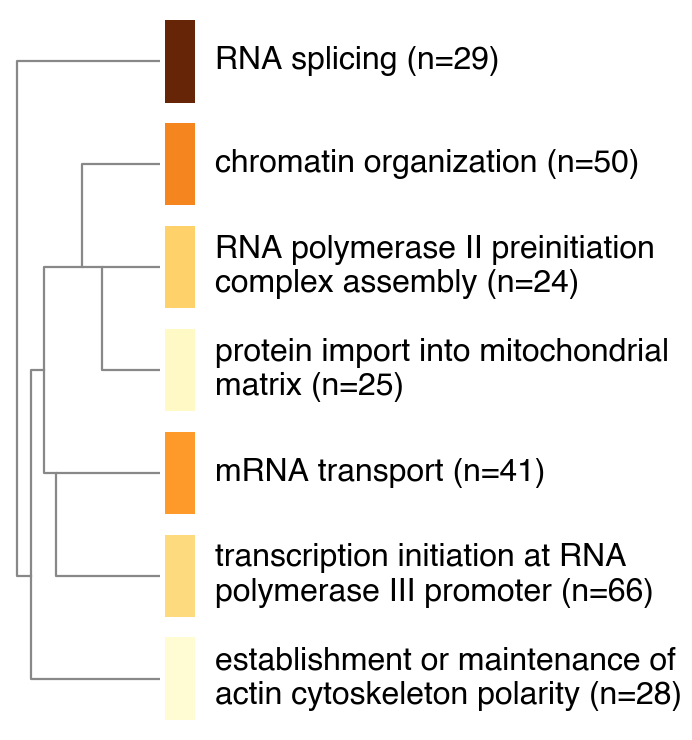

In [10]:
zoom_condensed = plot_dendrogram_condensed(
    zoom_results_sig,
    rank_by="q",
    label_mode="top_term",
    figsize=(5, 8),
    dendrogram_width=0.3,
    sigbar_cmap=ENRICHMENT_CMAP,
    sigbar_width=0.06,
    sigbar_height=0.8,
    sigbar_min_logp=0.0,
    sigbar_max_logp=30.0,
    font=FONT,
    fontsize=23,
    max_words=40,
    wrap_text=True,
    wrap_width=34,
    overflow="ellipsis",
    omit_words=(),
    label_fields=("label", "n"),
    label_color=LABEL_COLOR,
    label_left_pad=0.04,
    dendrogram_color=DENDRO_COLOR,
    dendrogram_lw=MATRIX_CONDENSED_LW,
    background_color=BACKGROUND_COLOR,
)
zoom_condensed.show()

# Optional: save figures locally (Binder storage is temporary).
SAVE_FIGURES = False

if SAVE_FIGURES:
    Path("outputs").mkdir(exist_ok=True)
    zoom_condensed.save(
        "outputs/quickstart_advanced_zoom_condensed.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.02,
    )